Data Understanding

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df=pd.read_csv("/content/DOC-20260503-WA0002.csv")

In [35]:
df.shape #Data types

(2250, 9)

In [36]:
df.head() #First 5 records

,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,Tesla,2016.0,2.3,Petrol,Manual,114832.0,New,26613.92,Model X
1,BMW,2018.0,4.4,Electric,Manual,143190.0,Used,14679.61,5 Series
2,Audi,2013.0,4.5,Electric,Manual,181601.0,New,44402.61,A4
3,Tesla,2011.0,4.1,Diesel,Automatic,68682.0,New,86374.33,Model Y
4,Ford,2009.0,2.6,Diesel,Manual,223009.0,Like New,73577.10,Mustang


In [37]:
df.columns #Understand features

Index(['Brand', 'Year', 'Engine Size', 'Fuel Type', 'Transmission', 'Mileage',
       'Condition', 'Price', 'Model'],
      dtype='object')

In [38]:
df.info() #Data types

<class 'pandas.core.frame.DataFrame'>
Index: 2250 entries, 0 to 2499
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         2250 non-null   object 
 1   Year          2250 non-null   float64
 2   Engine Size   2250 non-null   float64
 3   Fuel Type     2250 non-null   object 
 4   Transmission  2250 non-null   object 
 5   Mileage       2250 non-null   float64
 6   Condition     2250 non-null   object 
 7   Price         2250 non-null   float64
 8   Model         2250 non-null   object 
dtypes: float64(4), object(5)
memory usage: 175.8+ KB


In [39]:
df["Price"] #Target variable

,Price
0,26613.92
1,14679.61
2,44402.61
3,86374.33
4,73577.10
...,...
2494,90378.98
2495,61384.10
2496,24710.35
2498,46085.67


Data Cleaning

In [40]:
df.isnull().sum()  #Missing values

,0
Brand,0
Year,0
Engine Size,0
Fuel Type,0
Transmission,0
Mileage,0
Condition,0
Price,0
Model,0


In [41]:
(df.isnull().sum() / len(df)) * 100  #Missing %

,0
Brand,0.0
Year,0.0
Engine Size,0.0
Fuel Type,0.0
Transmission,0.0
Mileage,0.0
Condition,0.0
Price,0.0
Model,0.0


In [84]:
#Handle missing values

df["Mileage"].fillna(df["Mileage"].mean(), inplace=True)

/tmp/ipykernel_11882/1455879010.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Mileage"].fillna(df["Mileage"].mean(), inplace=True)
/tmp/ipykernel_11882/1455879010.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["Mileage"].fillna(df["Mileage"].mean(), inplace=True)


In [43]:
df["Fuel Type"].fillna("Unknown", inplace=True)

/tmp/ipykernel_11882/2048921617.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Fuel Type"].fillna("Unknown", inplace=True)


In [44]:
df.duplicated() #Check duplicates

,0
0,False
1,False
2,False
3,False
4,False
...,...
2494,False
2495,False
2496,False
2498,False


In [45]:
df = df.drop_duplicates() #Remove duplicates

In [61]:
df["Fuel Type"] = df["Fuel Type"].str.lower() #Standardize values

In [62]:
df[df["Price"] < 0] #Check unrealistic values

,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model


Univariate Analysis

In [46]:
df["Price"].describe() #Price

,Price
count,2250.000000
mean,52506.874391
std,27232.417079
min,5011.270000
25%,28985.052500
50%,53485.240000
75%,75560.340000
max,99982.590000


In [47]:
df["Mileage"].describe() #Mileage

,Mileage
count,2250.000000
mean,150236.178222
std,88150.746556
min,15.000000
25%,71178.500000
50%,149762.000000
75%,226299.000000
max,299967.000000


In [63]:
df["Engine Size"].describe() #Engine Size

,Engine Size
count,2250.000000
mean,3.485467
std,1.427690
min,1.000000
25%,2.300000
50%,3.450000
75%,4.700000
max,6.000000


In [64]:
df["Year"].describe()  #Year

,Year
count,2250.000000
mean,2011.577778
std,6.980468
min,2000.000000
25%,2005.000000
50%,2012.000000
75%,2018.000000
max,2023.000000


In [65]:
df["Price"].skew()  #Skewness

np.float64(-0.015321411512531361)

In [48]:
df["Brand"].value_counts() #Brand frequency

,count
Brand,
Toyota,346
Mercedes,331
BMW,326
Audi,323
Tesla,314
Ford,307
Honda,303


In [49]:
df["Fuel Type"].value_counts() #Fuel type

,count
Fuel Type,
Diesel,587
Petrol,561
Electric,554
Hybrid,548


In [66]:
df["Transmission"].value_counts()  #Transmission

,count
Transmission,
Manual,1184
Automatic,1066


In [50]:
df.groupby("Brand")["Price"].mean() #Brand vs Price

,Price
Brand,
Audi,52255.465263
BMW,54153.252914
Ford,51551.944560
Honda,51812.369439
Mercedes,53079.992205
Tesla,52677.920191
Toyota,51942.347890


In [51]:
df.groupby("Fuel Type")["Price"].mean() #Fuel vs Price

,Price
Fuel Type,
Diesel,54883.636440
Electric,50785.849097
Hybrid,52602.359416
Petrol,51626.237843


In [68]:
df.groupby("Transmission")["Price"].mean() #Transmission vs Price

,Price
Transmission,
Automatic,52267.806341
Manual,52722.116402


In [52]:
df.groupby("Year")["Price"].mean() #Year vs Price

,Price
Year,
2000.0,52432.790814
2001.0,49292.828932
2002.0,56420.336186
2003.0,54211.404900
2004.0,49509.242809
2005.0,56535.605789
2006.0,54136.829870
2007.0,56223.763762
2008.0,52705.700909


In [69]:
df.groupby("Mileage")["Price"].mean() #Mileage vs Price

,Price
Mileage,
15.0,41932.64
36.0,43288.37
45.0,66802.72
56.0,33444.21
64.0,29641.48
...,...
299355.0,40601.34
299461.0,78577.89
299738.0,94121.24


In [70]:
df.groupby("Engine Size")["Price"].mean() #Engine vs Price

,Price
Engine Size,
1.0,67032.023684
1.1,50802.757778
1.2,49778.452250
1.3,53799.912545
1.4,50506.231304
1.5,46235.715641
1.6,53256.180000
1.7,54435.750769
1.8,56166.172373


Multivariate Analysis

In [72]:
df.corr(numeric_only=True)  #Correlation matrix

,Year,Engine Size,Mileage,Price
Year,1.000000,0.011341,-0.006602,-0.035127
Engine Size,0.011341,1.000000,-0.018606,-0.013270
Mileage,-0.006602,-0.018606,1.000000,-0.009638
Price,-0.035127,-0.013270,-0.009638,1.000000


<Axes: >

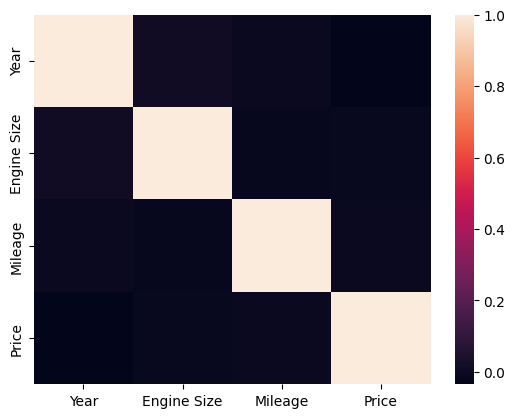

In [73]:
import seaborn as sns #Heatmap
sns.heatmap(df.corr(numeric_only=True))

In [74]:
df.corr(numeric_only=True)["Price"].sort_values() #Strong correlations

,Price
Year,-0.035127
Engine Size,-0.013270
Mileage,-0.009638
Price,1.000000


In [75]:
df[["Year","Mileage","Engine Size","Price"]].corr() #Combined effect

,Year,Mileage,Engine Size,Price
Year,1.000000,-0.006602,0.011341,-0.035127
Mileage,-0.006602,1.000000,-0.018606,-0.009638
Engine Size,0.011341,-0.018606,1.000000,-0.013270
Price,-0.035127,-0.009638,-0.013270,1.000000


Outlier Detection

In [76]:
q1 = df["Price"].quantile(0.25)
q3 = df["Price"].quantile(0.75)
iqr = q3 - q1
df[(df["Price"] < q1-1.5*iqr) | (df["Price"] > q3+1.5*iqr)]

,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model


In [77]:
#Mileage outliers
q1 = df["Mileage"].quantile(0.25)
q3 = df["Mileage"].quantile(0.75)
iqr = q3 - q1
df[(df["Mileage"] < q1-1.5*iqr) | (df["Mileage"] > q3+1.5*iqr)]

,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model


In [86]:
#Engine outliers
q1 = df["Engine Size"].quantile(0.25)
q3 = df["Engine Size"].quantile(0.75)
iqr = q3 - q1
df[(df["Engine Size"] < q1-1.5*iqr) | (df["Engine Size"] > q3+1.5*iqr)]

,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model,Age


In [79]:
df = df[(df["Price"] >= q1-1.5*iqr) & (df["Price"] <= q3+1.5*iqr)]

Business Insights

In [87]:
#Highest price brand
df.groupby("Brand")["Price"].mean().sort_values(ascending=False)

,Price
Brand,


In [88]:
#Automatic cost
df.groupby("Transmission")["Price"].mean()

,Price
Transmission,


In [89]:
#. Diesel value
df.groupby("Fuel Type")["Price"].mean()

,Price
Fuel Type,


In [80]:
#Mileage impact
df[["Mileage","Price"]].corr()

,Mileage,Price
Mileage,NaN,NaN
Price,NaN,NaN


In [81]:
#Age impact
df["Age"] = 2025 - df["Year"]
df[["Age","Price"]].corr()

,Age,Price
Age,NaN,NaN
Price,NaN,NaN


Important Features

In [57]:
df.corr(numeric_only=True)["Price"].sort_values(ascending=False)

,Price
Price,1.000000
Mileage,-0.009638
Engine Size,-0.013270
Year,-0.035127


Final Insights

1.New cars have higher price

2.Automatic cars cost more

3.Mileage reduces price

4.Engine size increases price

5.Some brands are premium